In [87]:
import pandas as pd
import warnings
pd.set_option("display.max_columns", None)
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima_process import ArmaProcess
from tqdm import tqdm
from itertools import product
from statsmodels.stats.diagnostic import acorr_ljungbox


## Preprocessing

In this part, I will import the data from the csv file and do some preprocessing steps like transform data types, rename columns, visualize the data. 

You'll see that the whole dataset has data since 1972. However, in reality, not many datasets have such a long history. Therefore, to make it relevant to other projects, I will just use data since 2010.

In [46]:
df = pd.read_csv("canada international travelers.csv",  delimiter=",")

In [47]:
df

,Month,International travellers entering or returning to Canada,Non-resident visitors entering Canada,United States of America residents entering Canada,"United States of America residents, air","United States of America residents, land","United States of America residents, water",Residents of countries other than the United States of America entering Canada,"Residents of countries other than the United States of America, air","Residents of countries other than the United States of America, land","Residents of countries other than the United States of America, water",Canadian-resident visitors returning to Canada,Canadian residents returning from the United States of America,"Canadian residents returning from the United States of America, air","Canadian residents returning from the United States of America, land","Canadian residents returning from the United States of America, water",Canadian residents returning from countries other than the United States of America,"Canadian residents returning from countries other than the United States of America, air","Canadian residents returning from countries other than the United States of America, land","Canadian residents returning from countries other than the United States of America, water",Other travellers entering or returning to Canada,Crew entering or returning to Canada,"Crew, United States of America residents entering Canada","Crew, residents of countries other than the United States of America entering Canada","Crew, Canadian residents returning to Canada",Other non-tourism related purposes
0,January 1972,"3,424,506","1,379,519","1,360,612","43,711","1,316,823",78,"18,907","11,784","7,115",8,"1,870,342","1,776,119","92,684","1,683,285",150,"94,223","84,590","9,594",39,"174,645","174,645","67,362",0,"107,283",0
1,February 1972,"3,290,221","1,431,063","1,409,881","61,811","1,347,802",268,"21,182","17,110","3,464",608,"1,685,711","1,617,609","92,578","1,525,011",20,"68,102","66,277","1,430",395,"173,447","173,447","66,634",0,"106,813",0
2,March 1972,"4,120,948","1,739,676","1,708,559","79,182","1,629,081",296,"31,117","23,264","7,853",0,"2,208,453","2,097,841","133,464","1,964,358",19,"110,612","106,915","3,697",0,"172,819","172,819","71,317",0,"101,502",0
3,April 1972,"4,801,257","2,098,156","2,055,510","84,630","1,970,598",282,"42,646","28,999","13,636",11,"2,538,543","2,452,398","128,877","2,323,409",112,"86,145","84,802","1,339",4,"164,558","164,558","70,498",0,"94,060",0
4,May 1972,"5,849,057","2,987,394","2,906,659","98,872","2,785,818","21,969","80,735","50,028","29,530","1,177","2,680,776","2,600,898","90,018","2,507,339","3,541","79,878","76,720","1,201","1,957","180,887","180,887","77,315",0,"103,572",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,February 2026,"5,408,197","1,478,633","1,140,552","279,030","857,723","3,799","338,081","307,905","29,711",465,"3,326,206","1,965,884","749,543","1,215,320","1,021","1,360,322","1,360,292",25,5,"603,358","538,464","63,832","41,693","432,939","64,894"
650,March 2026,"6,565,088","1,662,215","1,313,158","340,901","960,470","11,787","349,057","312,917","35,279",861,"4,214,270","2,584,339","934,145","1,645,703","4,491","1,629,931","1,629,825",66,40,"688,603","614,143","70,703","46,332","497,108","74,460"
651,April 2026,"6,356,894","1,886,926","1,454,250","366,572","1,046,931","40,747","432,676","380,351","48,702","3,623","3,776,851","2,393,095","805,904","1,578,592","8,599","1,383,756","1,383,010",71,675,"693,117","618,887","67,533","62,877","488,477","74,230"
652,May 2026,"7,425,581","2,891,190","2,225,875","510,005","1,441,984","273,886","665,315","533,856","77,121","54,338","3,702,374","2,550,542","703,732","1,803,242","43,568","1,151,832","1,147,911",83,"3,838","832,017","751,397","72,210","189,178","490,009","80,620"


In [48]:
df["Month"] = pd.to_datetime(df["Month"], format="%B %Y")

In [49]:
for col in df.columns:
    if col != "Month":
        df[col] = df[col].str.replace(',', '').astype(int)

In [50]:
df = df.rename(columns={
    "International travellers entering or returning to Canada": "Total",

    "Non-resident visitors entering Canada": "NonResident",

    "United States of America residents entering Canada": "US",
    "United States of America residents, air": "US_Air",
    "United States of America residents, land": "US_Land",
    "United States of America residents, water": "US_Water",

    "Residents of countries other than the United States of America entering Canada": "Overseas",
    "Residents of countries other than the United States of America, air": "Overseas_Air",
    "Residents of countries other than the United States of America, land": "Overseas_Land",
    "Residents of countries other than the United States of America, water": "Overseas_Water",

    "Canadian-resident visitors returning to Canada": "CanadianResident",

    "Canadian residents returning from the United States of America": "Canadian_US",
    "Canadian residents returning from the United States of America, air": "Canadian_US_Air",
    "Canadian residents returning from the United States of America, land": "Canadian_US_Land",
    "Canadian residents returning from the United States of America, water": "Canadian_US_Water",

    "Canadian residents returning from countries other than the United States of America": "Canadian_Overseas",
    "Canadian residents returning from countries other than the United States of America, air": "Canadian_Overseas_Air",
    "Canadian residents returning from countries other than the United States of America, land": "Canadian_Overseas_Land",
    "Canadian residents returning from countries other than the United States of America, water": "Canadian_Overseas_Water",

    "Other travellers entering or returning to Canada": "Other",

    "Crew entering or returning to Canada": "Crew",
    "Crew, United States of America residents entering Canada": "Crew_US",
    "Crew, residents of countries other than the United States of America entering Canada": "Crew_Overseas",
    "Crew, Canadian residents returning to Canada": "Crew_Canadian",

    "Other non-tourism related purposes": "Other_NonTourism"
})

In [51]:
df

,Month,Total,NonResident,US,US_Air,US_Land,US_Water,Overseas,Overseas_Air,Overseas_Land,Overseas_Water,CanadianResident,Canadian_US,Canadian_US_Air,Canadian_US_Land,Canadian_US_Water,Canadian_Overseas,Canadian_Overseas_Air,Canadian_Overseas_Land,Canadian_Overseas_Water,Other,Crew,Crew_US,Crew_Overseas,Crew_Canadian,Other_NonTourism
0,1972-01-01,3424506,1379519,1360612,43711,1316823,78,18907,11784,7115,8,1870342,1776119,92684,1683285,150,94223,84590,9594,39,174645,174645,67362,0,107283,0
1,1972-02-01,3290221,1431063,1409881,61811,1347802,268,21182,17110,3464,608,1685711,1617609,92578,1525011,20,68102,66277,1430,395,173447,173447,66634,0,106813,0
2,1972-03-01,4120948,1739676,1708559,79182,1629081,296,31117,23264,7853,0,2208453,2097841,133464,1964358,19,110612,106915,3697,0,172819,172819,71317,0,101502,0
3,1972-04-01,4801257,2098156,2055510,84630,1970598,282,42646,28999,13636,11,2538543,2452398,128877,2323409,112,86145,84802,1339,4,164558,164558,70498,0,94060,0
4,1972-05-01,5849057,2987394,2906659,98872,2785818,21969,80735,50028,29530,1177,2680776,2600898,90018,2507339,3541,79878,76720,1201,1957,180887,180887,77315,0,103572,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,2026-02-01,5408197,1478633,1140552,279030,857723,3799,338081,307905,29711,465,3326206,1965884,749543,1215320,1021,1360322,1360292,25,5,603358,538464,63832,41693,432939,64894
650,2026-03-01,6565088,1662215,1313158,340901,960470,11787,349057,312917,35279,861,4214270,2584339,934145,1645703,4491,1629931,1629825,66,40,688603,614143,70703,46332,497108,74460
651,2026-04-01,6356894,1886926,1454250,366572,1046931,40747,432676,380351,48702,3623,3776851,2393095,805904,1578592,8599,1383756,1383010,71,675,693117,618887,67533,62877,488477,74230
652,2026-05-01,7425581,2891190,2225875,510005,1441984,273886,665315,533856,77121,54338,3702374,2550542,703732,1803242,43568,1151832,1147911,83,3838,832017,751397,72210,189178,490009,80620


In [52]:
df.dtypes

Month                      datetime64[ns]
Total                               int64
NonResident                         int64
US                                  int64
US_Air                              int64
US_Land                             int64
US_Water                            int64
Overseas                            int64
Overseas_Air                        int64
Overseas_Land                       int64
Overseas_Water                      int64
CanadianResident                    int64
Canadian_US                         int64
Canadian_US_Air                     int64
Canadian_US_Land                    int64
Canadian_US_Water                   int64
Canadian_Overseas                   int64
Canadian_Overseas_Air               int64
Canadian_Overseas_Land              int64
Canadian_Overseas_Water             int64
Other                               int64
Crew                                int64
Crew_US                             int64
Crew_Overseas                     

In [56]:
df = df[df['Month'] >= '01-01-2010']

Text(0.5, 1.0, "The total number of Canada's International Travelers over the period from 2010 to 2026 (Unit: 10M)")

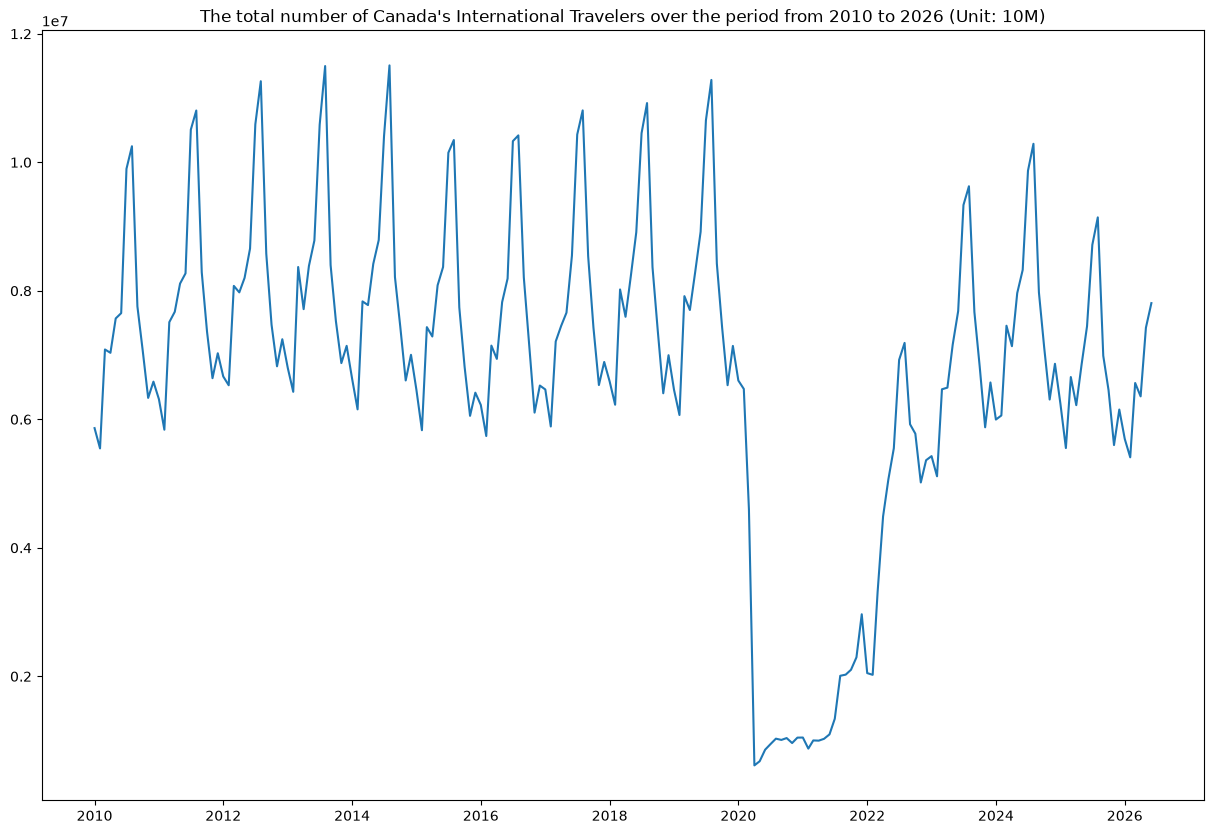

In [57]:
plt.figure(figsize=(15,10))

plt.plot(df[['Month']],df[['Total']])

plt.title("The total number of Canada's International Travelers over the period from 2010 to 2026 (Unit: 10M)")

### Test the stationarity

- Why do we need to test the stationarity? "A stationary time series is the series that has a constant mean, variance, and autocorrelation. These properties **do not change over time**. MA, AR, ARMA models assume stationarity.
- How to test? I use **Augmented Dickey-Fuller (ADF)** test. ADF runs an autoregressive model to check how strongly past value predict future values. If p-value is low, we can reject the Null hypothesis and conclude the data is stationary.
​


In [58]:
from statsmodels.tsa.stattools import adfuller
 
ADF_result = adfuller(df['Total'])  

print(f'ADF Statistic: {ADF_result[0]}')     
print(f'p-value: {ADF_result[1]}') 

ADF Statistic: -3.2360562984238794
p-value: 0.017990191141548838


p-value = 0.017... < 0.05, so we can reject the Null hypothesis. The series is stationary.

### Autocorrelation
- What is it? Autocorrelation measures the linear relationship between lagged values of a time series. For example, with lag = 1: we have the correlation between the current value and it's value in time t-1
- What if the series has no autocorrelations? It means past values cannot predict future values using simple linear models. In another word, it is a random walk. Our statistical models cannot be used.

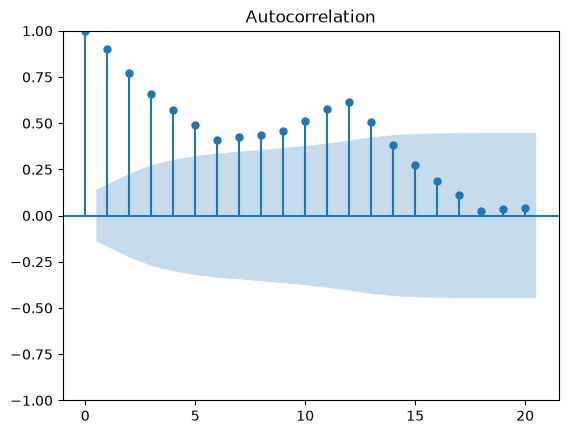

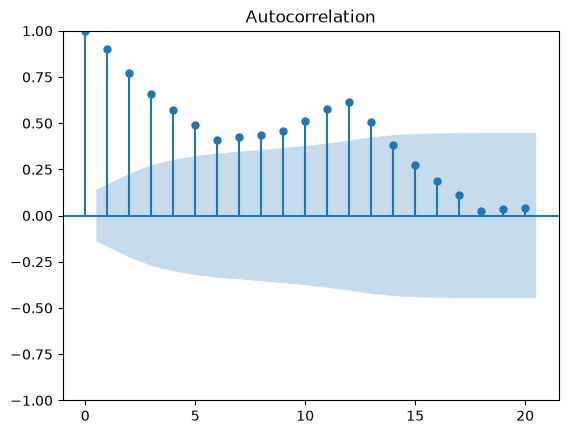

In [60]:
from statsmodels.graphics.tsaplots import plot_acf
 
plot_acf(df['Total'], lags=20)

We can see that the autocorrelation starts to go down lower than the confidence interval at lag 14

# Modelling

In this project, I evaluated several classical statistical time-series forecasting methods and compared their performance against simple baseline models. The goal was to determine whether more sophisticated models could capture meaningful temporal and seasonal patterns and provide more accurate forecasts than straightforward forecasting strategies.

**Statistical models evaluated:**

* **MA (Moving Average):** Uses past forecast errors to model the current value of the time series.
* **AR (Autoregressive):** Uses previous observations of the time series to predict future values.
* **ARMA (Autoregressive Moving Average):** Combines AR and MA components to model both relationships with past observations and past forecast errors.
* **SARIMA (Seasonal ARIMA):** Extends ARIMA by explicitly modeling recurring seasonal patterns, making it suitable for time series with systematic seasonal behavior such as monthly or yearly cycles.

**Baseline Models:**

To provide meaningful benchmarks, I also evaluated three simple forecasting approaches:

* **Mean:** Predicts future values using the historical average.
* **Last:** Uses the most recent observed value as the forecast.
* **Last Seasonal:** Uses the value from the corresponding period in the previous season. For example, for monthly data, the forecast for January uses the previous January's value.



In [62]:
#Predict 6 months in 2026

df_train = df[['Total']].iloc[:len(df)-6]
df_test = df[['Total']].iloc[len(df)-6:]

In [71]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df, train_len, test_len, window, method) -> list:
    total_len = train_len + test_len

    if method == "mean":
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean
    
    elif method == "last":
        pred_last = []
        for i in range(train_len, total_len, window):
            last = df[:i].iloc[-1].values[0]
            pred_last.extend(last for _ in range(window))
        return pred_last  

    elif method == "MA":
        pred_MA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0,0,12))                 
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]    
            pred_MA.extend(oos_pred)
            
        return pred_MA 

    elif method == 'AR':
        pred_AR = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(12,0,0))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)

        return pred_AR 

    elif method == 'ARMA':
        pred_ARMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(12,0,12))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)            
            
        return pred_ARMA          


In [79]:
pred_df = df_test.copy()
 
TRAIN_LEN = len(df_train)
TEST_LEN = len(df_test)
WINDOW = 1
 
pred_mean = rolling_forecast(df_train, TRAIN_LEN, TEST_LEN, WINDOW, 'mean')
pred_last = rolling_forecast(df_train, TRAIN_LEN, TEST_LEN, WINDOW,'last')
pred_MA = rolling_forecast(df_train, TRAIN_LEN, TEST_LEN, WINDOW, 'MA')
pred_AR = rolling_forecast(df_train, TRAIN_LEN, TEST_LEN, WINDOW, 'AR')
pred_ARMA = rolling_forecast(df_train, TRAIN_LEN, TEST_LEN, WINDOW, 'ARMA')
 
pred_df['pred_mean'] = pred_mean
pred_df['pred_last'] = pred_last
pred_df['pred_MA'] = pred_MA
pred_df['pred_AR'] = pred_AR
pred_df['pred_ARMA'] = pred_ARMA
 
pred_df

,Total,pred_mean,pred_last,pred_MA,pred_AR,pred_ARMA
648,5694588,6.801670e+06,6151814,5.454285e+06,5.942852e+06,5.786140e+06
649,5408197,6.801670e+06,6151814,4.489956e+06,5.556284e+06,5.391678e+06
650,6565088,6.801670e+06,6151814,3.938144e+06,6.520535e+06,6.491550e+06
651,6356894,6.801670e+06,6151814,2.913963e+06,5.948673e+06,6.150130e+06
652,7425581,6.801670e+06,6151814,2.399496e+06,6.609370e+06,6.863593e+06
653,7808169,6.801670e+06,6151814,1.731738e+06,6.840566e+06,7.172734e+06


In [82]:
df.tail()

,Month,Total,NonResident,US,US_Air,US_Land,US_Water,Overseas,Overseas_Air,Overseas_Land,Overseas_Water,CanadianResident,Canadian_US,Canadian_US_Air,Canadian_US_Land,Canadian_US_Water,Canadian_Overseas,Canadian_Overseas_Air,Canadian_Overseas_Land,Canadian_Overseas_Water,Other,Crew,Crew_US,Crew_Overseas,Crew_Canadian,Other_NonTourism
649,2026-02-01,5408197,1478633,1140552,279030,857723,3799,338081,307905,29711,465,3326206,1965884,749543,1215320,1021,1360322,1360292,25,5,603358,538464,63832,41693,432939,64894
650,2026-03-01,6565088,1662215,1313158,340901,960470,11787,349057,312917,35279,861,4214270,2584339,934145,1645703,4491,1629931,1629825,66,40,688603,614143,70703,46332,497108,74460
651,2026-04-01,6356894,1886926,1454250,366572,1046931,40747,432676,380351,48702,3623,3776851,2393095,805904,1578592,8599,1383756,1383010,71,675,693117,618887,67533,62877,488477,74230
652,2026-05-01,7425581,2891190,2225875,510005,1441984,273886,665315,533856,77121,54338,3702374,2550542,703732,1803242,43568,1151832,1147911,83,3838,832017,751397,72210,189178,490009,80620
653,2026-06-01,7808169,3767868,2956889,725628,1855638,375623,810979,691189,86094,33696,3180470,2274040,546456,1700485,27099,906430,903476,78,2876,859831,782296,79651,206040,496605,77535


## Visualizations

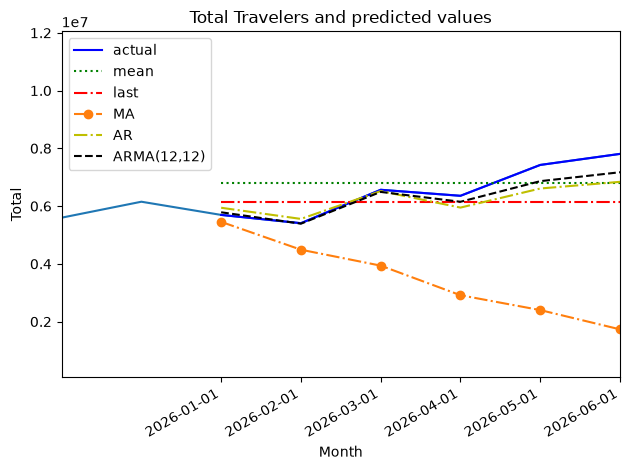

In [86]:
fig, ax = plt.subplots()
 
ax.plot(df['Total'])
ax.plot(pred_df['Total'], 'b-', label='actual')
ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_last'], 'r-.', label='last')
ax.plot(pred_df['pred_MA'], 'o-.', label='MA')
ax.plot(pred_df['pred_AR'], 'y-.', label='AR')
ax.plot(pred_df['pred_ARMA'], 'k--', label='ARMA(12,12)')
ax.legend(loc=2)
ax.set_xlabel('Month')
ax.set_ylabel('Total')
 
# ax.axvspan(6, 650, color='#808080', alpha=0.2)     
 
ax.set_xlim(646, 653)                                
 
plt.xticks(
    [648, 649, 650, 651, 652, 653],
    ['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', "2026-06-01"])
 
fig.autofmt_xdate()

plt.title("Total Travelers and predicted values")
plt.tight_layout()

## Evaluations

For evaluations, we use 3 main metrics:
- MAPE: 
- MSE: 
- MAE: 

In [66]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true-y_pred)/y_true))*100

In [ ]:

df_eval = pd.DataFrame(columns=["Method","MAPE","MSE","MAE"])

columns = ["pred_mean","pred_last","pred_MA","pred_AR","pred_ARMA"]
methods = ["mean","last","MA","AR","ARMA"]

for m in methods:

    pred_col = "pred_"+m

    df_eval.loc[len(df_eval)] = [
    m,
    mape(pred_df['Total'], pred_df['pred_'+m]),
    mean_squared_error(pred_df['Total'], pred_df['pred_'+m]),
    mean_absolute_error(pred_df['Total'], pred_df['pred_'+m])
    ]

df_eval

,Method,MAPE,MSE,MAE
0,mean,12.849966,8.039166e+11,8.020538e+05
1,last,11.611158,8.901449e+11,7.915532e+05
2,MA,43.480087,1.364001e+13,3.055156e+06
3,AR,6.263707,3.091084e+11,4.388231e+05
4,ARMA,3.665371,1.294037e+11,2.642993e+05


In [24]:
from typing import Union

def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm(order_list):
        try: 
            model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [25]:
ps = range(10, 20, 1)                   
qs = range(10, 20, 1)                   
 
order_list = list(product(ps, qs))

In [26]:
order_list

[(10, 10),
 (10, 11),
 (10, 12),
 (10, 13),
 (10, 14),
 (10, 15),
 (10, 16),
 (10, 17),
 (10, 18),
 (10, 19),
 (11, 10),
 (11, 11),
 (11, 12),
 (11, 13),
 (11, 14),
 (11, 15),
 (11, 16),
 (11, 17),
 (11, 18),
 (11, 19),
 (12, 10),
 (12, 11),
 (12, 12),
 (12, 13),
 (12, 14),
 (12, 15),
 (12, 16),
 (12, 17),
 (12, 18),
 (12, 19),
 (13, 10),
 (13, 11),
 (13, 12),
 (13, 13),
 (13, 14),
 (13, 15),
 (13, 16),
 (13, 17),
 (13, 18),
 (13, 19),
 (14, 10),
 (14, 11),
 (14, 12),
 (14, 13),
 (14, 14),
 (14, 15),
 (14, 16),
 (14, 17),
 (14, 18),
 (14, 19),
 (15, 10),
 (15, 11),
 (15, 12),
 (15, 13),
 (15, 14),
 (15, 15),
 (15, 16),
 (15, 17),
 (15, 18),
 (15, 19),
 (16, 10),
 (16, 11),
 (16, 12),
 (16, 13),
 (16, 14),
 (16, 15),
 (16, 16),
 (16, 17),
 (16, 18),
 (16, 19),
 (17, 10),
 (17, 11),
 (17, 12),
 (17, 13),
 (17, 14),
 (17, 15),
 (17, 16),
 (17, 17),
 (17, 18),
 (17, 19),
 (18, 10),
 (18, 11),
 (18, 12),
 (18, 13),
 (18, 14),
 (18, 15),
 (18, 16),
 (18, 17),
 (18, 18),
 (18, 19),
 (19, 10),

In [27]:
pd.set_option("display.max_columns", None)

In [29]:
result_df = optimize_ARMA(df_train['Total'], order_list)
result_df

  0%|          | 0/100 [00:00<?, ?it/s]/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
  1%|          | 1/100 [00:00<00:49,  2.00it/s]/Users/hai-yennguyen/Docu

,"(p,q)",AIC
0,"(10, 10)",5678.491512
1,"(11, 10)",5680.800685
2,"(10, 11)",5681.547091
3,"(12, 12)",5681.658396
4,"(12, 10)",5682.769607
...,...,...
95,"(11, 17)",5705.025814
96,"(11, 19)",5706.689294
97,"(16, 19)",5707.156272
98,"(10, 18)",5708.959763


In [30]:
result_df.head(10)

,"(p,q)",AIC
0,"(10, 10)",5678.491512
1,"(11, 10)",5680.800685
2,"(10, 11)",5681.547091
3,"(12, 12)",5681.658396
4,"(12, 10)",5682.769607
5,"(14, 12)",5683.102983
6,"(11, 11)",5683.254073
7,"(13, 12)",5683.753759
8,"(10, 12)",5684.472425
9,"(15, 12)",5685.017916


/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


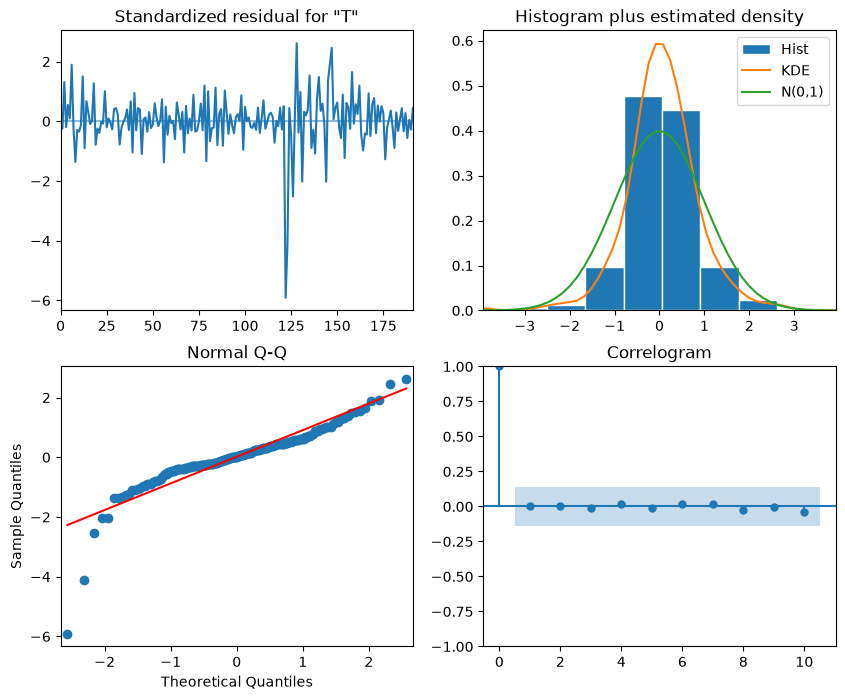

In [32]:
model = SARIMAX(df_train['Total'], order=(10,0,10), simple_differencing=False)
model_fit = model.fit(disp=False)

model_fit.plot_diagnostics(figsize=(10, 8));


In [33]:
residuals = model_fit.resid
 
acorr_ljungbox(residuals, np.arange(1, 20, 1))
 


,lb_stat,lb_pvalue
1,0.123321,0.725460
2,2.096706,0.350514
3,2.299926,0.512535
4,3.079826,0.544557
5,3.098376,0.684822
6,7.652048,0.264719
7,7.680742,0.361586
8,8.787183,0.360566
9,8.845868,0.451622
10,8.992988,0.532769


# Updated models

In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df, train_len, test_len, window, method) -> list:
    total_len = train_len + test_len

    if method == "mean":
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean
    
    elif method == "last":
        pred_last = []
        for i in range(train_len, total_len, window):
            last = df[:i].iloc[-1].values[0]
            pred_last.extend(last for _ in range(window))
        return pred_last  
    
    elif method == "MA":
        pred_MA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0,0,12))       #MA = 12           
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]    #Out of sample pred
            pred_MA.extend(oos_pred)
            
        return pred_MA 

    elif method == 'AR':
        pred_AR = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(12,0,0))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)
            
        return pred_AR     


    elif method == 'ARMA':
        pred_ARMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(10,0,10))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)
            
        return pred_ARMA          


In [35]:
pred_df = df_test.copy()
 
TRAIN_LEN = len(df_train)
TEST_LEN = len(df_test)
WINDOW = 1
 
pred_mean = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'mean')
pred_last = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW,'last')
pred_MA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'MA')
pred_AR = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'AR')
pred_ARMA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'ARMA')
 
pred_df['pred_mean'] = pred_mean
pred_df['pred_last'] = pred_last
pred_df['pred_MA'] = pred_MA
pred_df['pred_AR'] = pred_AR
pred_df['pred_ARMA'] = pred_ARMA
 
pred_df.head()

/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_mo

,Total,pred_mean,pred_last,pred_MA,pred_AR,pred_ARMA
648,5694588,6.801670e+06,6151814,5.454285e+06,5.942852e+06,5.719904e+06
649,5408197,6.795934e+06,5694588,4.812985e+06,5.187412e+06,5.325924e+06
650,6565088,6.788780e+06,5408197,5.082028e+06,6.494351e+06,6.628337e+06
651,6356894,6.787633e+06,6565088,6.096212e+06,6.065698e+06,6.130781e+06
652,7425581,6.785436e+06,6356894,6.027360e+06,7.184694e+06,7.136466e+06


In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
 
mse_mean = mean_absolute_error(pred_df['Total'], pred_df['pred_mean'])
mse_last = mean_absolute_error(pred_df['Total'], pred_df['pred_last'])
mse_MA = mean_absolute_error(pred_df['Total'], pred_df['pred_MA'])
mse_AR = mean_absolute_error(pred_df['Total'], pred_df['pred_AR'])
mse_ARMA = mean_absolute_error(pred_df['Total'], pred_df['pred_ARMA'])

print(mape(pred_df['Total'], pred_df['pred_mean']))
print(mape(pred_df['Total'], pred_df['pred_last']))
print(mape(pred_df['Total'], pred_df['pred_MA']))
print(mape(pred_df['Total'], pred_df['pred_AR']))
print(mape(pred_df['Total'], pred_df['pred_ARMA']))
 
print(mse_mean, mse_last, mse_MA, mse_AR, mse_ARMA)

12.82691895000686
8.918899034000837
11.457123970223108
3.2741176019884057
1.851754944678383
801479.9486422967 593329.5 766976.3084916691 208580.9013454509 123854.8705651847


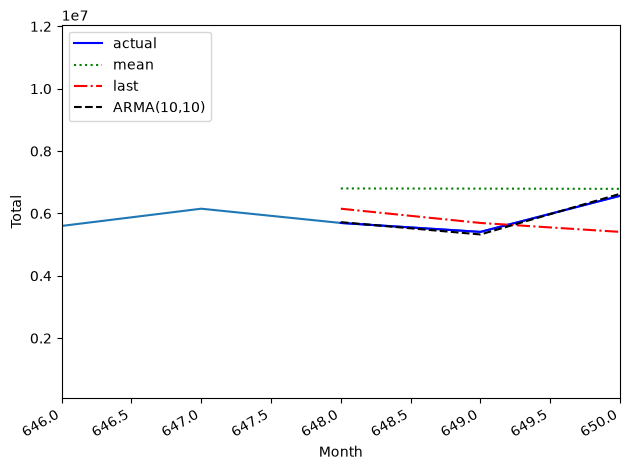

In [38]:
fig, ax = plt.subplots()
 
ax.plot(df['Total'])
ax.plot(pred_df['Total'], 'b-', label='actual')
ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_last'], 'r-.', label='last')
ax.plot(pred_df['pred_ARMA'], 'k--', label='ARMA(10,10)')
ax.legend(loc=2)
ax.set_xlabel('Month')
ax.set_ylabel('Total')
 
# ax.axvspan(600, 650, color='#808080', alpha=0.2)     
 
ax.set_xlim(646, 650)                                
 
# plt.xticks(
#     [9802, 9850, 9898, 9946, 9994],
#     ['2020-02-13', '2020-02-15', '2020-02-17', '2020-02-19', '2020-02-21'])
 
fig.autofmt_xdate()
plt.tight_layout()

# Add seasonal cycles

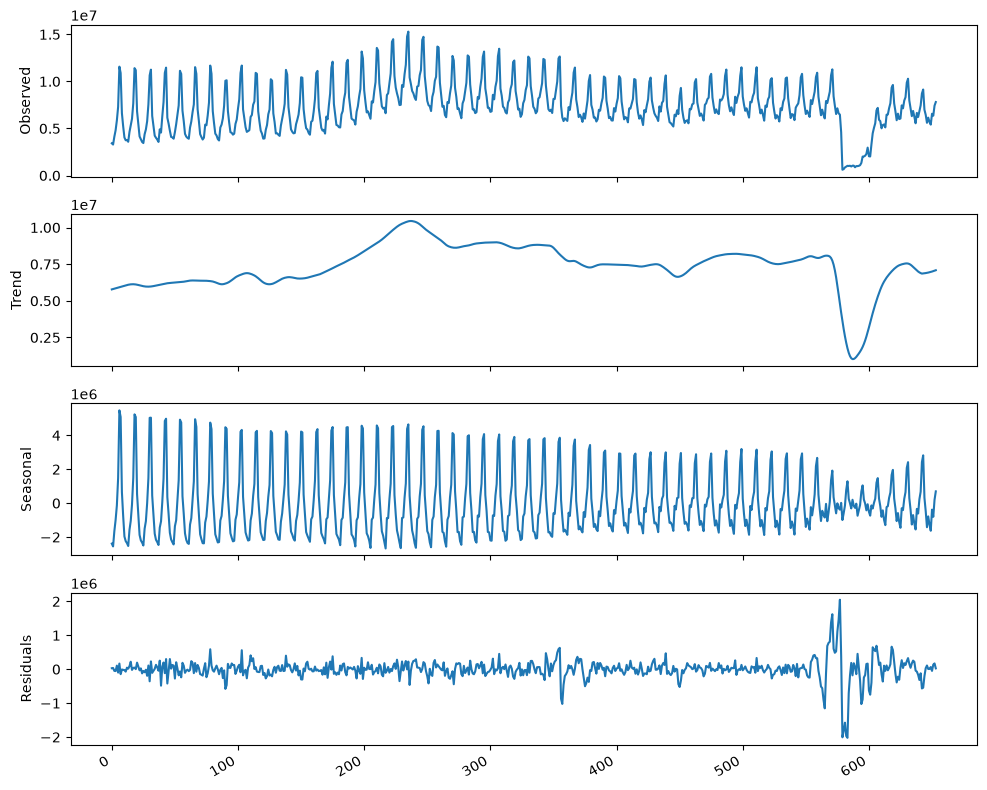

In [ ]:
from statsmodels.tsa.seasonal import STL
 
decomposition = STL(df['Travelers'], period=12).fit()      
 
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))                                          
 
ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')
 
ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')
 
ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
 
ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')
 
# plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))
 
fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX
 
def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:      
    
    results = []
    
    for order in tqdm(order_list):   
        try:
            model = SARIMAX(
                endog, 
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
        
        aic = model.aic
        results.append([order, aic])
    
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [ ]:
ps = range(12, 18, 1)                                                     
qs = range(12, 18, 1)
Ps = range(0, 4, 1)
Qs = range(0, 4, 1)
 
SARIMA_order_list = list(product(ps, qs, Ps, Qs))                                                              
 
d = 0
D = 0
s = 12
 
SARIMA_result_df = optimize_SARIMA(df_train, SARIMA_order_list, d, D, s)   
SARIMA_result_df     

  0%|          | 0/576 [00:00<?, ?it/s]/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
  0%|          | 1/576 [00:01<18:16,  1.91s/it]/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
  3%|▎         | 17/576 [00:03<01:51,  5.02it/s]/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
  6%|▌         | 33/576 [00:06<01:30,  6.02it/s]/Users/hai-yennguyen/Documents/Projects/.venv/l

,"(p,q,P,Q)",AIC
0,"(14, 14, 0, 0)",18736.273573
1,"(17, 16, 0, 0)",18743.039275
2,"(15, 14, 0, 0)",18743.517191
3,"(15, 17, 0, 0)",18743.721950
4,"(16, 14, 0, 0)",18745.737007
5,"(14, 15, 0, 0)",18745.750972
6,"(14, 13, 0, 0)",18747.078487
7,"(16, 15, 0, 0)",18748.309280
8,"(15, 15, 0, 0)",18749.855650
9,"(13, 17, 0, 0)",18750.210922


In [ ]:
ps = range(0, 4, 1)                                                     
qs = range(0, 4, 1)
Ps = range(0, 4, 1)
Qs = range(0, 4, 1)
 
SARIMA_order_list = list(product(ps, qs, Ps, Qs))                                                              
 
d = 0
D = 0
s = 12
 
SARIMA_result_df = optimize_SARIMA(df_train, SARIMA_order_list, d, D, s)   
SARIMA_result_df     

  0%|          | 0/256 [00:00<?, ?it/s]/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
  6%|▋         | 16/256 [00:06<03:08,  1.27it/s]/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarima

,"(p,q,P,Q)",AIC
0,"(3, 3, 1, 2)",19507.740794
1,"(3, 3, 2, 1)",19508.720555
2,"(2, 3, 1, 2)",19508.940316
3,"(3, 3, 3, 1)",19509.176850
4,"(3, 3, 2, 2)",19509.763079
...,...,...
250,"(0, 0, 0, 3)",21875.337465
251,"(0, 0, 0, 2)",21893.075247
252,"(0, 1, 0, 0)",21917.795732
253,"(0, 0, 0, 1)",21973.739700


/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


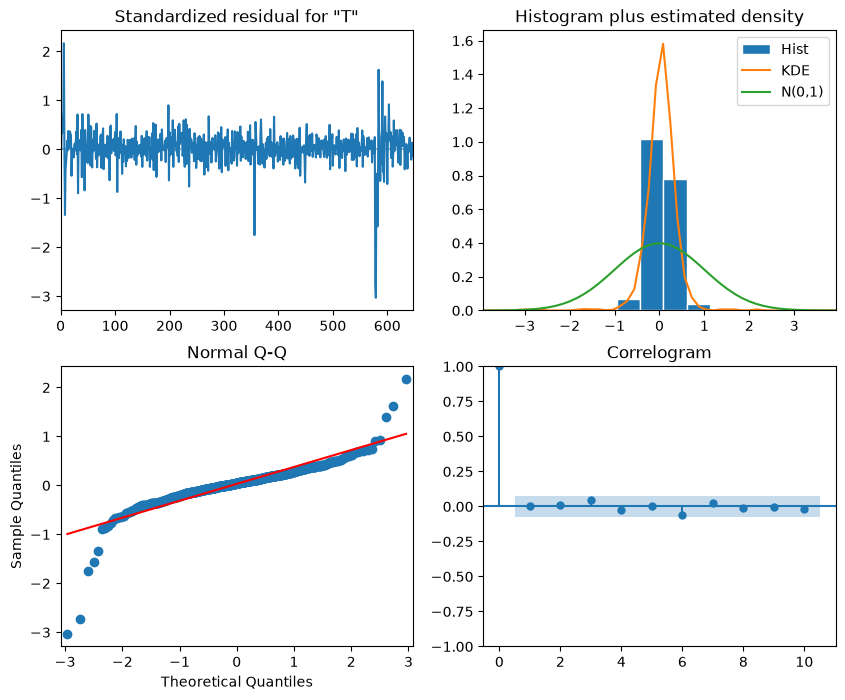

In [ ]:
SARIMA_model = SARIMAX(df_train, order=(3,0,3), seasonal_order=(1,0,2,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)
 
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
 
residuals = SARIMA_model_fit.resid
 
acorr_ljungbox(residuals, np.arange(1, 11, 1))

,lb_stat,lb_pvalue
1,2.087748,0.148485
2,2.208751,0.331418
3,3.067009,0.381409
4,3.157650,0.531798
5,3.229098,0.664713
6,3.828782,0.699834
7,3.866170,0.795057
8,6.452868,0.596640
9,6.723361,0.665896
10,7.089528,0.716967


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df, train_len, test_len, window, method) -> list:
    total_len = train_len + test_len

    if method == "mean":
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean
    
    elif method == "last":
        pred_last = []
        for i in range(train_len, total_len, window):
            last = df[:i].iloc[-1].values[0]
            pred_last.extend(last for _ in range(window))
        return pred_last  
    
    elif method == "MA":
        pred_MA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0,0,12))       #MA = 12           
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]    #Out of sample pred
            pred_MA.extend(oos_pred)
            
        return pred_MA 

    elif method == 'AR':
        pred_AR = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(12,0,0))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)
            
        return pred_AR     


    elif method == 'ARMA':
        pred_ARMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(14,0,14))      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)
            
        return pred_ARMA   
           

    elif method == 'SARMA':
        pred_SARMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(3,0,3), seasonal_order=(1,0,2,12), simple_differencing=False)      
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARMA.extend(oos_pred)
            
        return pred_SARMA   

In [ ]:
pred_df = df_test.copy()
 
TRAIN_LEN = len(df_train)
TEST_LEN = len(df_test)
WINDOW = 1
 
pred_mean = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'mean')
pred_last = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW,'last')
pred_MA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'MA')
pred_AR = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'AR')
pred_ARMA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'ARMA')
pred_SARMA = rolling_forecast(df_model, TRAIN_LEN, TEST_LEN, WINDOW, 'SARMA')
 
pred_df['pred_mean'] = pred_mean
pred_df['pred_last'] = pred_last
pred_df['pred_MA'] = pred_MA
pred_df['pred_AR'] = pred_AR
pred_df['pred_ARMA'] = pred_ARMA
pred_df['pred_SARMA'] = pred_SARMA
 
pred_df.head()

/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/hai-yennguyen/Documents/Projects/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting pa

,Travelers,pred_mean,pred_last,pred_MA,pred_AR,pred_ARMA,pred_SARMA
648,5694588,7.362064e+06,6151814,5.625575e+06,6.047574e+06,5.612582e+06,5.710149e+06
649,5408197,7.359495e+06,5694588,4.774967e+06,5.309287e+06,5.340296e+06,5.143848e+06
650,6565088,7.356493e+06,5408197,5.415321e+06,6.558263e+06,6.528188e+06,6.387996e+06
651,6356894,7.355277e+06,6565088,6.219879e+06,6.169326e+06,6.256122e+06,6.141677e+06
652,7425581,7.353746e+06,6356894,6.228664e+06,7.133142e+06,7.051463e+06,6.870558e+06


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
 
mse_mean = mean_absolute_error(pred_df['Travelers'], pred_df['pred_mean'])
mse_last = mean_absolute_error(pred_df['Travelers'], pred_df['pred_last'])
mse_MA = mean_absolute_error(pred_df['Travelers'], pred_df['pred_MA'])
mse_AR = mean_absolute_error(pred_df['Travelers'], pred_df['pred_AR'])
mse_ARMA = mean_absolute_error(pred_df['Travelers'], pred_df['pred_ARMA'])
mse_SARMA = mean_absolute_error(pred_df['Travelers'], pred_df['pred_SARMA'])

print(mape(pred_df['Travelers'], pred_df['pred_mean']))
print(mape(pred_df['Travelers'], pred_df['pred_last']))
print(mape(pred_df['Travelers'], pred_df['pred_MA']))
print(mape(pred_df['Travelers'], pred_df['pred_AR']))
print(mape(pred_df['Travelers'], pred_df['pred_ARMA']))
print(mape(pred_df['Travelers'], pred_df['pred_SARMA']))
 
print(mse_mean, mse_last, mse_MA, mse_AR, mse_ARMA, mse_SARMA)

16.651376061821342
8.918899034000837
8.549043161524885
2.915261237344274
1.7039281686143586
3.158713920918152
989118.4426098898 593329.5 564644.6134955791 188614.0125165088 114739.25555123186 207579.92135152966
